# Audio Classification using Neural Networks

## Project Objective

The objective of this project is to classify audio recordings into different categories using a Neural Network.

### Project Workflow

1. Load the audio dataset
2. Explore the dataset
3. Extract MFCC features from audio files
4. Prepare the data for training
5. Build and train a Neural Network
6. Evaluate model performance
7. Make predictions on unseen audio samples

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
import librosa
import librosa.display


## Loading the Dataset Metadata

Most audio classification datasets contain:

- Audio files (.wav)
- A metadata file (.csv)

The metadata file acts as a map between:

- Audio file names
- Their corresponding class labels

Before extracting features, we must understand:

- Number of audio samples
- Number of classes
- Available columns in the dataset
- Distribution of classes

In [8]:
metadata = pd.read_csv(r"D:\AI_ML\Audio-Classification-Neural-Network\audio_data\UrbanSound8K.csv")

In [10]:
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [11]:
metadata.shape

(8732, 8)

In [12]:
metadata.columns

Index(['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold',
       'classID', 'class'],
      dtype='object')

In [13]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB


## Loading a Sample Audio File

Audio files are stored as waveforms.

A waveform is simply a sequence of amplitude values recorded over time.

Before extracting features, it is useful to visualize an audio signal and understand:

- Sampling Rate
- Number of Samples
- Duration of Audio
- Waveform Shape

In [14]:
sample_row = metadata.iloc[0]

sample_row

slice_file_name    100032-3-0-0.wav
fsID                         100032
start                           0.0
end                        0.317551
salience                          1
fold                              5
classID                           3
class                      dog_bark
Name: 0, dtype: object

In [15]:
sample_row["slice_file_name"]

'100032-3-0-0.wav'

In [16]:
sample_row["fold"]

np.int64(5)

## Creating the Audio File Path

The metadata provides:

- File name
- Fold number

These are combined to locate the actual audio file inside the dataset.

In [22]:
audio_path=(r"D:\AI_ML\Audio-Classification-Neural-Network\audio_data\fold"
            + str(sample_row["fold"])
            + "\\"
            + sample_row["slice_file_name"]
            )

audio_path

'D:\\AI_ML\\Audio-Classification-Neural-Network\\audio_data\\fold5\\100032-3-0-0.wav'

In [23]:
import os

os.path.exists(audio_path)

True

## Loading an Audio File

The audio file is loaded using Librosa.

Librosa returns:

1. Audio Signal (array of numbers)
2. Sample Rate

The audio signal contains amplitude values recorded over time.

The sample rate indicates how many samples are recorded per second.

In [24]:
import librosa
import librosa.display

In [25]:
audio, sample_rate= librosa.load(audio_path)

In [26]:
type(audio)

numpy.ndarray

In [27]:
audio.shape

(7002,)

In [28]:
sample_rate

22050

In [29]:
duration = len(audio) / sample_rate

print("Duration:", duration, "seconds")

Duration: 0.31755102040816324 seconds


## Visualizing the Audio Waveform

A waveform is a graphical representation of an audio signal.

- X-axis represents Time
- Y-axis represents Amplitude

The waveform helps us understand how the sound changes over time.

This is the raw audio signal before any feature extraction is performed.

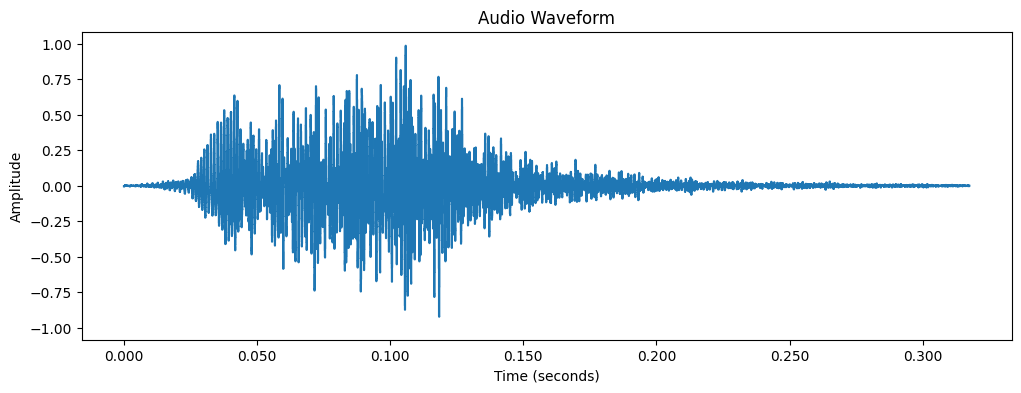

In [31]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sample_rate
)

plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

## MFCC Feature Extraction

Machine Learning models do not work efficiently with raw audio signals.

Therefore, we extract MFCC (Mel Frequency Cepstral Coefficients) features.

MFCCs capture the important frequency characteristics of an audio signal while reducing dimensionality.

These features will be used as inputs to the Neural Network.

In [32]:
mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

mfccs.shape

(40, 14)

## Creating a Fixed-Length Feature Vector

Different audio files may have different durations, resulting in different numbers of MFCC frames.

To create a fixed-size input for the Neural Network, we calculate the mean of each MFCC coefficient across all time frames.

This converts the MFCC matrix into a single feature vector of length 40.

In [33]:
mfccs_scaled = np.mean(
    mfccs.T,
    axis=0
)

mfccs_scaled.shape

(40,)

In [35]:
mfccs_scaled

array([-2.1193698e+02,  6.2581207e+01, -1.2281315e+02, -6.0745293e+01,
       -1.3893760e+01, -2.9789835e+01, -3.9788749e+00,  1.1682742e+01,
        1.2963828e+01,  8.3364210e+00, -6.5298190e+00, -2.9961064e+00,
       -1.2887950e+01,  5.8859324e+00, -2.4752254e+00, -4.4083118e+00,
       -1.5014478e+01, -9.4399697e-01, -2.5799103e+00,  6.0982966e+00,
       -1.0786229e+01, -8.0634775e+00,  5.8440900e+00, -3.1225376e+00,
       -5.9842277e+00, -7.9944745e-02, -3.6870894e+00,  4.7476764e+00,
       -6.5300946e+00, -5.0838842e+00,  4.8772603e-01,  7.5108857e+00,
       -8.8535994e-01,  2.3938141e+00, -6.3923717e+00, -2.1318593e+00,
        2.2760150e+00, -7.9108363e-01, -1.5400676e+00,  1.3211496e+00],
      dtype=float32)

## Creating a Feature Extraction Function

To process thousands of audio files efficiently, we create a reusable function.

The function performs the following steps:

1. Load the audio file
2. Extract 40 MFCC features
3. Compute the mean across all time frames
4. Return a fixed-length feature vector of size 40

This function will later be applied to every audio file in the dataset.

In [36]:
def extract_features(file_path):

    audio, sample_rate = librosa.load(file_path)

    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    mfccs_scaled = np.mean(
        mfccs.T,
        axis=0
    )

    return mfccs_scaled

In [37]:
features = extract_features(audio_path)

features.shape

(40,)

In [38]:
features[:5]

array([-211.93698 ,   62.581207, -122.81315 ,  -60.745293,  -13.89376 ],
      dtype=float32)

## Understanding the Metadata Structure

Before extracting features for all audio files, we inspect the metadata again.

We need:

- File name column
- Fold column
- Class label column

These columns will help us locate every audio file and assign its correct label.

In [39]:
metadata[['slice_file_name', 'fold', 'class']].head()

,slice_file_name,fold,class
0,100032-3-0-0.wav,5,dog_bark
1,100263-2-0-117.wav,5,children_playing
2,100263-2-0-121.wav,5,children_playing
3,100263-2-0-126.wav,5,children_playing
4,100263-2-0-137.wav,5,children_playing


## Testing Feature Extraction on a Small Sample

Before processing the entire dataset, we test the feature extraction pipeline on the first 5 audio files.

This helps verify that:

- Audio paths are correct
- Audio files can be loaded
- MFCC features are extracted successfully
- Labels are assigned correctly

In [44]:
extracted_features=[]

for index_num, row in metadata.head().iterrows():
   file_path=(
    r"D:\AI_ML\Audio-Classification-Neural-Network\audio_data\fold"
    + str(row["fold"])
    + "\\"
    + row["slice_file_name"]
    )
   
   data=extract_features(file_path)

   extracted_features.append([
      data,
      row["class"]
   ])
   
print("Total Processed Files:", len(extracted_features))



Total Processed Files: 5


In [45]:
extracted_features[0]

[array([-2.1193698e+02,  6.2581207e+01, -1.2281315e+02, -6.0745293e+01,
        -1.3893760e+01, -2.9789835e+01, -3.9788749e+00,  1.1682742e+01,
         1.2963828e+01,  8.3364210e+00, -6.5298190e+00, -2.9961064e+00,
        -1.2887950e+01,  5.8859324e+00, -2.4752254e+00, -4.4083118e+00,
        -1.5014478e+01, -9.4399697e-01, -2.5799103e+00,  6.0982966e+00,
        -1.0786229e+01, -8.0634775e+00,  5.8440900e+00, -3.1225376e+00,
        -5.9842277e+00, -7.9944745e-02, -3.6870894e+00,  4.7476764e+00,
        -6.5300946e+00, -5.0838842e+00,  4.8772603e-01,  7.5108857e+00,
        -8.8535994e-01,  2.3938141e+00, -6.3923717e+00, -2.1318593e+00,
         2.2760150e+00, -7.9108363e-01, -1.5400676e+00,  1.3211496e+00],
       dtype=float32),
 'dog_bark']

## Creating a DataFrame from Extracted Features

The extracted features and labels are currently stored in a Python list.

To make the data easier to inspect and process, we convert it into a Pandas DataFrame.

Each row represents:

- MFCC feature vector
- Corresponding class label

In [46]:
features_df = pd.DataFrame(
    extracted_features,
    columns=["feature", "class"]
)

features_df

,feature,class
0,"[-211.93698, 62.581207, -122.81315, -60.745293...",dog_bark
1,"[-417.0052, 99.336624, -42.995586, 51.073326, ...",children_playing
2,"[-452.39316, 112.36253, -37.57807, 43.195866, ...",children_playing
3,"[-406.47922, 91.1966, -25.043558, 42.78452, 11...",children_playing
4,"[-439.63873, 103.86224, -42.658783, 50.690277,...",children_playing


## Extracting Features from the Entire Dataset

We now apply the feature extraction function to every audio file in the dataset.

For each audio file:

1. Load the audio
2. Extract 40 MFCC features
3. Compute the mean feature vector
4. Store the feature vector along with its class label

The resulting dataset will be used for training the Neural Network.

In [49]:
from tqdm import tqdm

extracted_features = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata)):

    file_path = (
        r"D:\AI_ML\Audio-Classification-Neural-Network\audio_data\fold"
        + str(row["fold"])
        + "\\"
        + row["slice_file_name"]
    )

    data = extract_features(file_path)

    extracted_features.append([
        data,
        row["class"]
    ])

 41%|████      | 3554/8732 [02:00<02:56, 29.26it/s]d:\AI_ML\Audio-Classification-Neural-Network\audio_ann_venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
 95%|█████████▌| 8326/8732 [04:57<00:15, 26.90it/s]d:\AI_ML\Audio-Classification-Neural-Network\audio_ann_venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
d:\AI_ML\Audio-Classification-Neural-Network\audio_ann_venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
100%|██████████| 8732/8732 [05:13<00:00, 27.82it/s]


In [50]:
len(extracted_features)

8732

## Creating the Final Dataset

The extracted features are currently stored as a Python list.

We convert them into a Pandas DataFrame so that the data can be easily inspected and prepared for machine learning.

Each row contains:

- A 40-dimensional MFCC feature vector
- The corresponding class label

In [51]:
features_df = pd.DataFrame(
    extracted_features,
    columns=["feature", "class"]
)

features_df.head()

,feature,class
0,"[-211.93698, 62.581207, -122.81315, -60.745293...",dog_bark
1,"[-417.0052, 99.336624, -42.995586, 51.073326, ...",children_playing
2,"[-452.39316, 112.36253, -37.57807, 43.195866, ...",children_playing
3,"[-406.47922, 91.1966, -25.043558, 42.78452, 11...",children_playing
4,"[-439.63873, 103.86224, -42.658783, 50.690277,...",children_playing


## Separating Features and Labels

Machine Learning models require:

- X → Input Features
- y → Target Labels

The MFCC vectors become the input features (X), while the audio classes become the target labels (y).

In [58]:
X = np.array(features_df["feature"].tolist())
#y = np.array(features_df["class"].tolist()) In this case we have to apply label encoder
y = metadata["classID"].values

In [59]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (8732, 40)
y Shape: (8732,)


## Train-Test Split

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6985, 40)
X_test : (1747, 40)
y_train: (6985,)
y_test : (1747,)


## Feature Scaling

The extracted MFCC features have different numerical ranges.

Neural Networks generally perform better when input features are standardized.

StandardScaler transforms the features so that:

- Mean ≈ 0
- Standard Deviation ≈ 1

This helps the model converge faster during training.

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Building the Neural Network

A simple feed-forward neural network is used for classification.

Architecture:

- Input Layer: 40 MFCC features
- Hidden Layer 1: 100 neurons
- Hidden Layer 2: 200 neurons
- Output Layer: 10 neurons (one for each sound class)

ReLU activation is used in hidden layers.

Softmax activation is used in the output layer to produce class probabilities.

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [71]:
model = Sequential()

# Hidden Layer 1
model.add(Dense(
    100,
    input_shape=(40,),
    activation='relu'
))

model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(
    200,
    activation='relu'
))

model.add(Dropout(0.3))

# Output Layer
model.add(Dense(
    10,
    activation='softmax'
))



In [72]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,310 (102.77 KB)

 Trainable params: 26,310 (102.77 KB)

 Non-trainable params: 0 (0.00 B)

Dropout is a regularization technique used to reduce overfitting. During training, it randomly disables a fraction of neurons, preventing the network from relying too heavily on specific neurons and improving generalization on unseen data.

In [73]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [74]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3846 - loss: 1.8064 - val_accuracy: 0.5741 - val_loss: 1.3323
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5558 - loss: 1.3209 - val_accuracy: 0.6707 - val_loss: 1.0964
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6178 - loss: 1.1434 - val_accuracy: 0.6908 - val_loss: 0.9681
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6514 - loss: 1.0490 - val_accuracy: 0.7273 - val_loss: 0.8816
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6766 - loss: 0.9664 - val_accuracy: 0.7459 - val_loss: 0.8208
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6988 - loss: 0.8968 - val_accuracy: 0.7523 - val_loss: 0.7823
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7181 - loss: 0.8515 - val_accuracy: 0.7731 - val_loss: 0.7401
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7387 - loss: 0.7950 - val_accuracy: 0.

## Model Evaluation on Test Data

After training, the model is evaluated on the testing dataset.

The testing dataset was never used during training.

This provides an unbiased estimate of the model's real-world performance.

In [75]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8867 - loss: 0.3783 
Test Accuracy: 0.8866628408432007
Test Loss: 0.3782786726951599


## Training History Visualization

The training history is visualized to analyze the learning behavior of the neural network.

The following graphs show:

- Training Accuracy vs Validation Accuracy
- Training Loss vs Validation Loss

These plots help identify:

- Underfitting
- Overfitting
- Convergence behavior

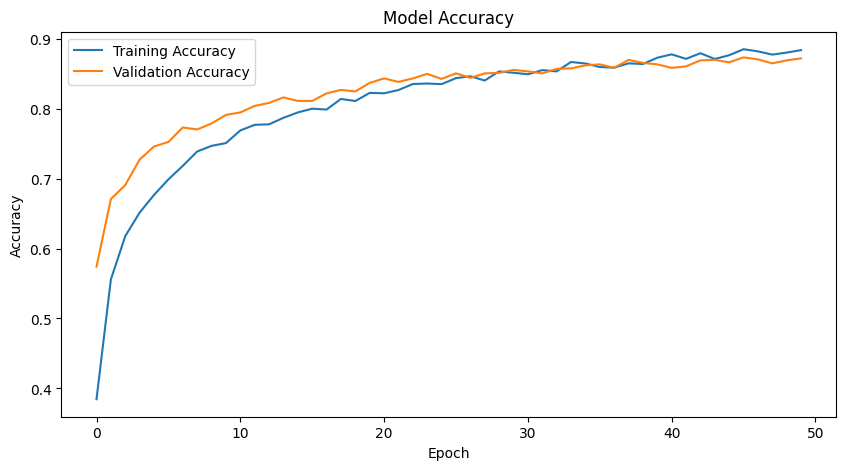

In [76]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

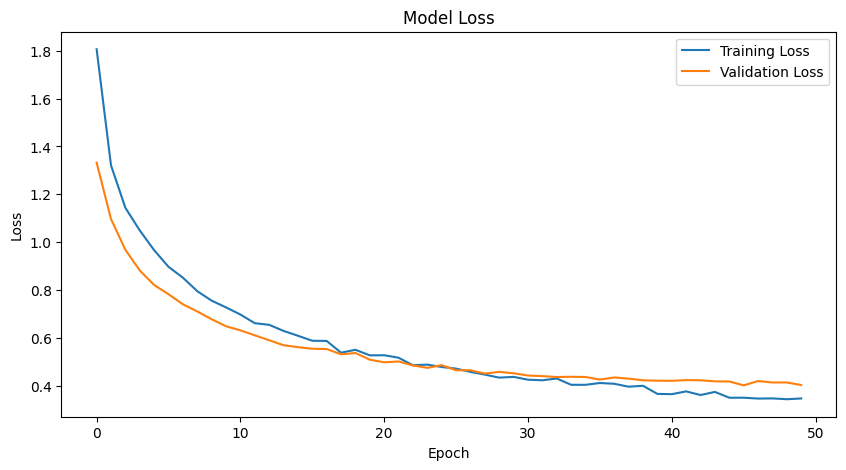

In [77]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Observation

The training and validation accuracy curves increase steadily and remain close to each other throughout training.

Similarly, both training and validation loss decrease consistently.

This indicates that the model is learning meaningful patterns from the MFCC features while maintaining good generalization performance without significant overfitting.